Great 👍 this is an important topic in **Feature Engineering**.

I’ll explain all topics from the image clearly and in order:

---

# 🔢 1. Encoding Numerical Features

In ML, numerical features can be:

* **Continuous** → e.g., age = 23.5, salary = 54321
* **Discrete** → e.g., number of rooms = 3

Sometimes we convert numerical → categorical to:

* Reduce noise
* Handle non-linearity
* Improve interpretability
* Work better with tree or linear models

This conversion is called:

> 🔁 **Discretization (Binning)**

---

# 📦 2. Discretization

### 📌 Definition

Discretization means converting a **continuous numerical feature** into **categorical bins (intervals)**.

Example:

| Age | After Binning |
| --- | ------------- |
| 18  | Young         |
| 27  | Young         |
| 45  | Middle        |
| 70  | Old           |

So instead of exact numbers, we group them into ranges.

---

# 🧩 3. Types of Discretization

From your image, main types are:

1. Equal Width / Uniform Binning
2. Equal Frequency / Quantile Binning
3. KMeans Binning
4. Custom / Domain Based Binning
5. Binarization

Let’s understand each clearly.

---

# 📏 4. Equal Width (Uniform) Binning

### 📌 Idea:

Divide the range into equal-sized intervals.

### Formula:

```
Bin Width = (Max - Min) / Number of Bins
```

### Example:

Data:
`[10, 20, 30, 40, 50]`

Range = 50 - 10 = 40
Suppose 2 bins:

Width = 40 / 2 = 20

Bins:

* Bin1: 10–30
* Bin2: 30–50

### ✅ Advantages:

* Simple
* Fast

### ❌ Disadvantages:

* Uneven data distribution
* One bin may contain most data

Used when data is uniformly distributed.

---

# 📊 5. Equal Frequency (Quantile Binning)

Also called:

> 🔹 Quantile Binning
> 🔹 Equal Frequency Binning

### 📌 Idea:

Each bin contains **equal number of data points**.

Example:

Data (sorted):
`[10, 20, 30, 40, 50, 60]`

2 bins → 3 values per bin:

* Bin1: [10,20,30]
* Bin2: [40,50,60]

### 📌 Uses quantiles:

* 25% → Q1
* 50% → Median
* 75% → Q3

### ✅ Advantages:

* Balanced distribution
* Works well for skewed data

### ❌ Disadvantages:

* Unequal width
* Harder to interpret

Very common in ML pipelines.

---

# 🎯 6. KMeans Binning

### 📌 Idea:

Use **K-Means clustering** to create bins.

Instead of dividing by range or frequency, it:

* Groups similar values using clustering
* Each cluster = one bin

### Example:

Data:
`[1,2,3,50,51,52]`

K=2 → clusters:

* Cluster1: [1,2,3]
* Cluster2: [50,51,52]

Much smarter than equal width.

### ✅ Advantages:

* Data-driven
* Handles non-uniform data well

### ❌ Disadvantages:

* Computationally expensive
* Needs choosing K

Used when distribution is complex.

---

# 🏷 7. Encoding the Discretized Variable

After binning, we must encode it.

Suppose:

| Salary | Bin    |
| ------ | ------ |
| 20000  | Low    |
| 50000  | Medium |
| 90000  | High   |

Now encode:

### Option 1: Label Encoding

Low = 0
Medium = 1
High = 2

### Option 2: One-Hot Encoding

| Low | Medium | High |
| --- | ------ | ---- |
| 1   | 0      | 0    |

---

# 🧠 8. Custom / Domain Based Binning

Here we use **domain knowledge**.

Example:

Age groups:

* 0–12 → Child
* 13–19 → Teen
* 20–59 → Adult
* 60+ → Senior

This is very useful in:

* Healthcare
* Finance
* Marketing

---

# ⚫ 9. Binarization

### 📌 Definition:

Convert numerical feature into 0 or 1 based on threshold.

### Example:

Threshold = 50

| Marks | After Binarization |
| ----- | ------------------ |
| 80    | 1                  |
| 45    | 0                  |
| 60    | 1                  |

Formula:

```
if x > threshold → 1
else → 0
```

### Used in:

* Pass/Fail
* Fraud detection
* Logistic regression

---

# 🆚 Difference Summary

| Method       | How it Divides          | Best For         |
| ------------ | ----------------------- | ---------------- |
| Equal Width  | Equal range size        | Uniform data     |
| Quantile     | Equal number of samples | Skewed data      |
| KMeans       | Clustering based        | Complex patterns |
| Custom       | Domain knowledge        | Business logic   |
| Binarization | Single threshold        | Yes/No decisions |

---

# 🏁 When Should You Use Binning?

✅ When:

* Model is linear but relation is non-linear
* Reduce impact of outliers
* Improve interpretability
* Feature has too many unique values

❌ Avoid when:

* Deep learning (it handles continuous data well)
* You lose too much information

---

# 💻 Simple Sklearn Example

```python
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np

X = np.array([[10], [20], [30], [40], [50]])

kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
X_binned = kbd.fit_transform(X)

print(X_binned)
```

Strategies:

* 'uniform' → Equal width
* 'quantile' → Equal frequency
* 'kmeans' → KMeans binning

---

# 🎯 Final Intuition

Think of discretization like:

> Turning a thermometer reading into: Cold / Warm / Hot.

You lose precision but gain clarity.

---

If you want, I can also:

* Draw diagram explanation
* Give interview-focused explanation
* Or give real ML project example 🔥


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
import numpy as np


In [2]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.fillna({'Age':df['Age'].median()},inplace=True)

In [4]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('Survived',axis=1),df['Survived'],test_size=0.2,random_state=42)

In [5]:
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
print("Accuracy: ",accuracy_score(y_pred,y_test))

Accuracy:  0.664804469273743


In [6]:
x_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,28.0,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [7]:
ct=ColumnTransformer([
    ('first',KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile', quantile_method='averaged_inverted_cdf'),[0]),
    ('second',KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile', quantile_method='averaged_inverted_cdf'),[1]),
])

In [8]:
X_train_trf=ct.fit_transform(x_train)
                                          
X_test_trf=ct.fit_transform(x_test)

c:\All_Coding_Work\ML Concepts\.mlevn\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\All_Coding_Work\ML Concepts\.mlevn\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [9]:
clf=DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred=clf.predict(X_test_trf)
print("Accuracy: ",accuracy_score(y_pred,y_test))


Accuracy:  0.6312849162011173


In [10]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})
output['age_labels'] = pd.cut(x=x_train['Age'],
                                    bins=ct.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=x_train['Fare'],
                                    bins=ct.named_transformers_['second'].bin_edges_[0].tolist())

In [11]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
80,22.0,3.0,9.0000,5.0,"(20.0, 23.0]","(8.458, 10.5]"
467,56.0,11.0,26.5500,10.0,"(52.0, 71.0]","(26.0, 27.721]"
520,30.0,6.0,93.5000,14.0,"(29.0, 31.0]","(89.104, 262.375]"
289,22.0,3.0,7.7500,2.0,"(20.0, 23.0]","(7.229, 7.75]"
623,21.0,3.0,7.8542,2.0,"(20.0, 23.0]","(7.75, 7.854]"


In [12]:
x=df.drop('Survived',axis=1)
y=df['Survived']
X_trf = ct.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

c:\All_Coding_Work\ML Concepts\.mlevn\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


np.float64(0.6599750312109862)

In [13]:
import matplotlib.pyplot as plt

In [14]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6634082397003744


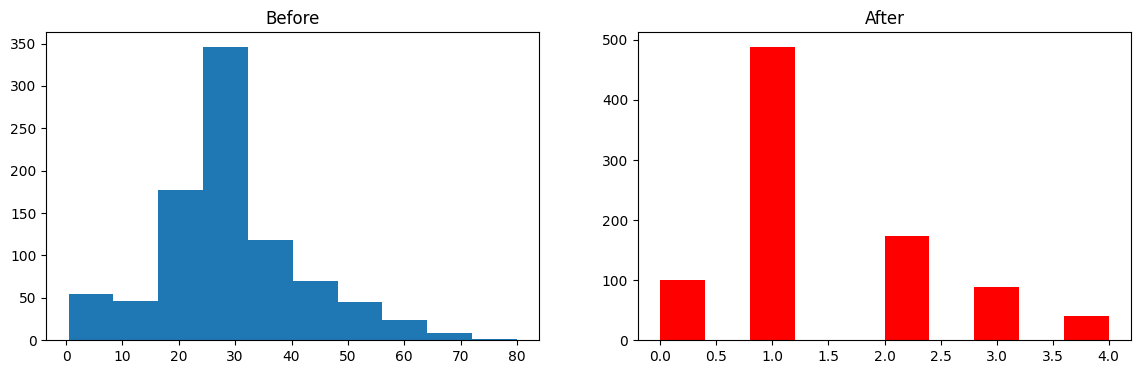

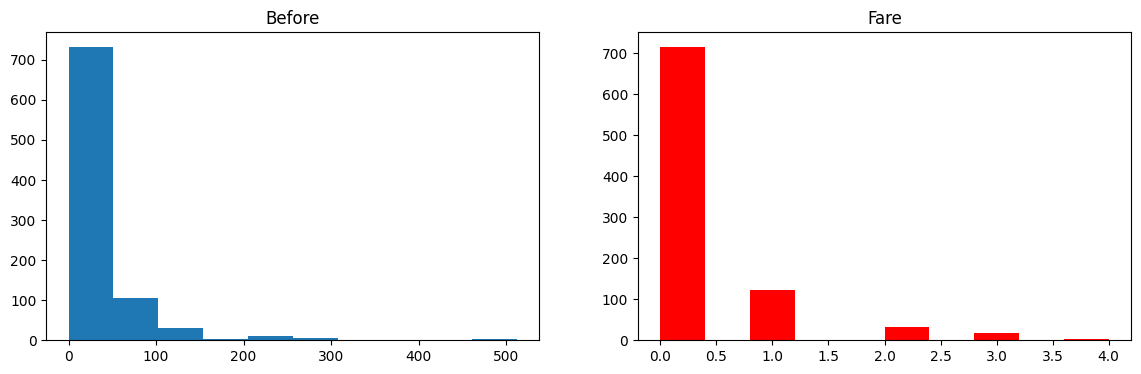

In [15]:
discretize(5,'kmeans')

c:\All_Coding_Work\ML Concepts\.mlevn\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\All_Coding_Work\ML Concepts\.mlevn\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\All_Coding_Work\ML Concepts\.mlevn\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by defaul

0.665692883895131


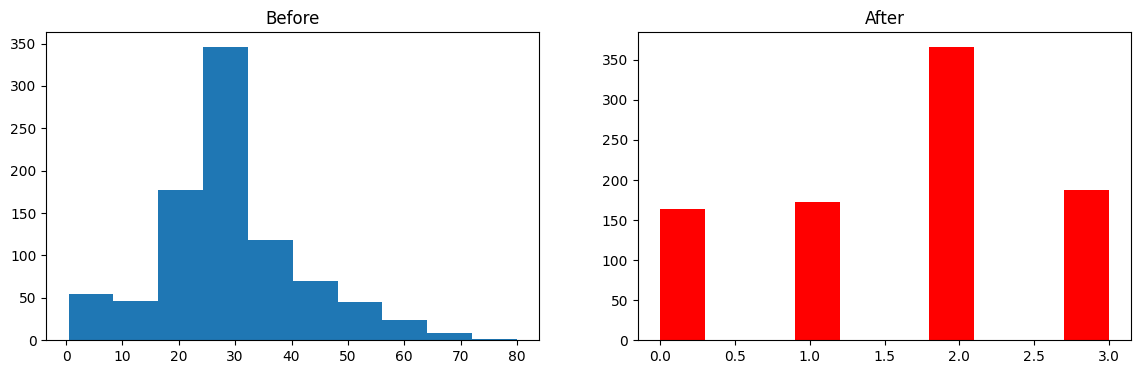

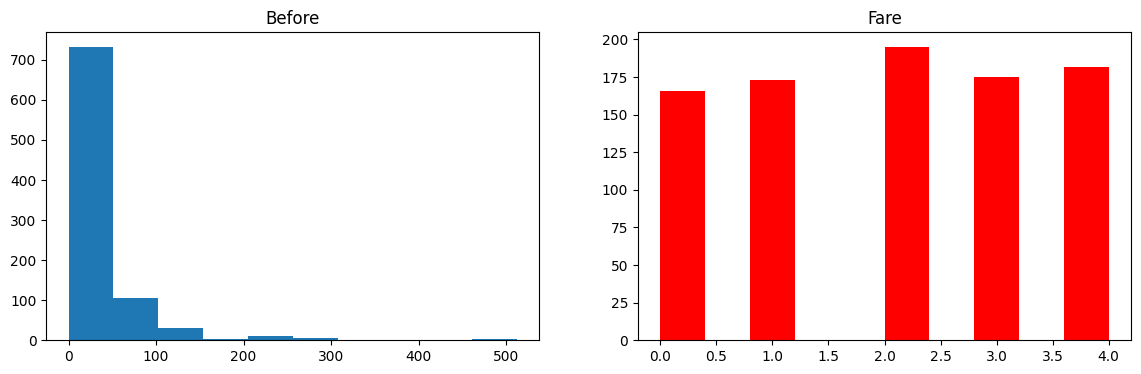

In [16]:
discretize(5,'quantile')


0.6420349563046193


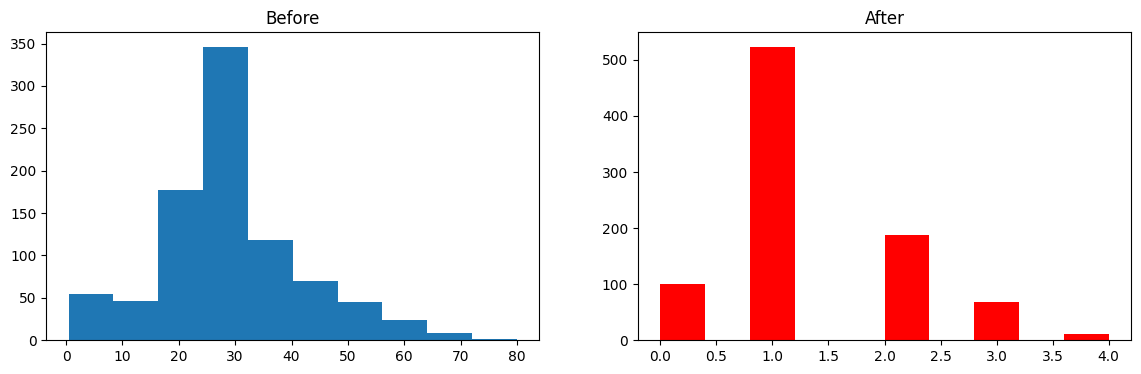

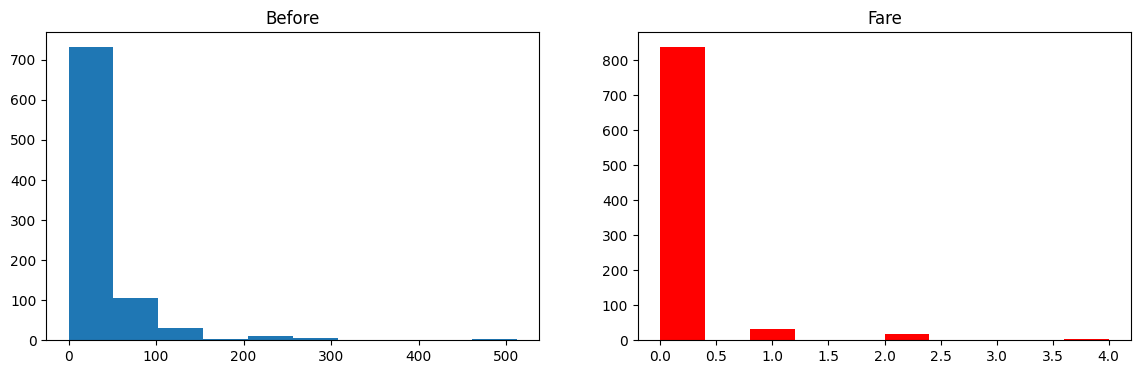

In [17]:
discretize(5,'uniform')
